
[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


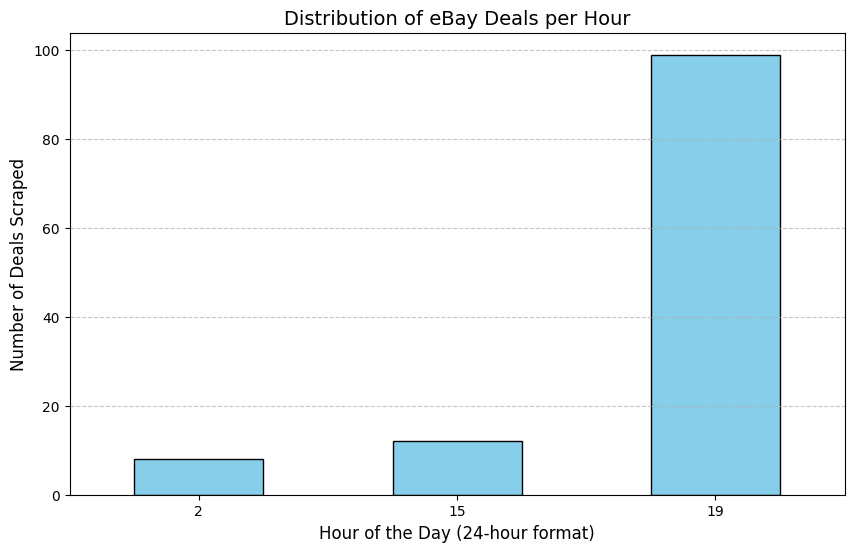

In [1]:
%pip install matplotlib pandas
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('cleaned_ebay_deals.csv')
# 1. Time Series Analysis

#convert timestamp to datetime and sort
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by='timestamp')

#extract hour and group them
df['hour'] = df['timestamp'].dt.hour
deals_per_hour = df.groupby('hour').size()

#bar chart showing the number of deals per hour
plt.figure(figsize=(10, 6))
deals_per_hour.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribution of eBay Deals per Hour', fontsize=14)
plt.xlabel('Hour of the Day (24-hour format)', fontsize=12)
plt.ylabel('Number of Deals Scraped', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

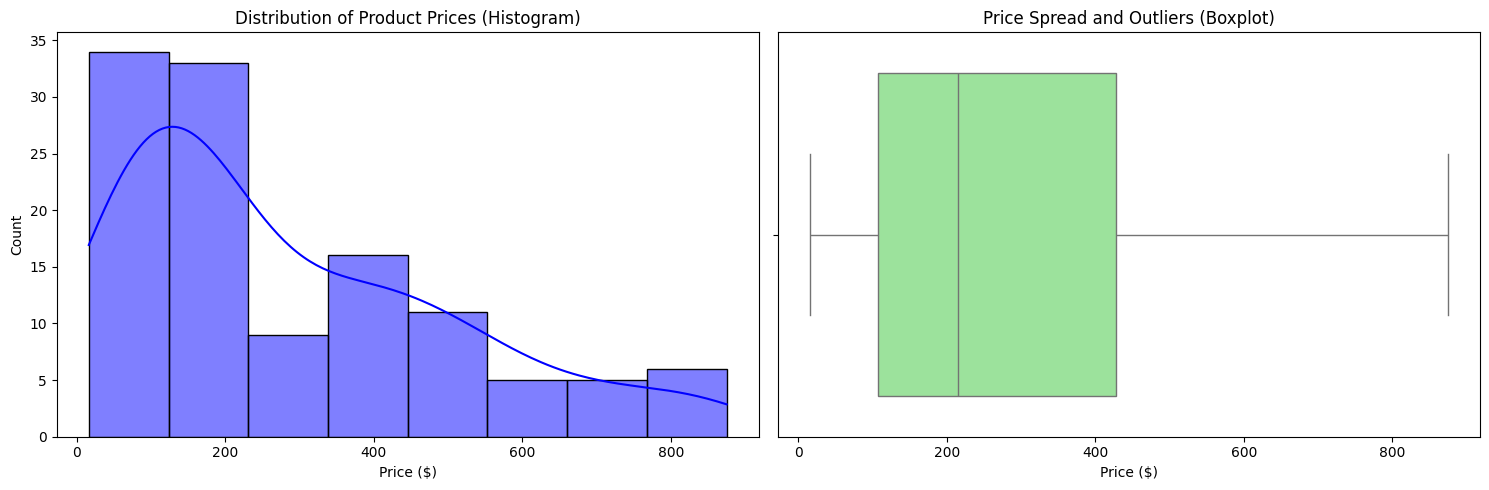

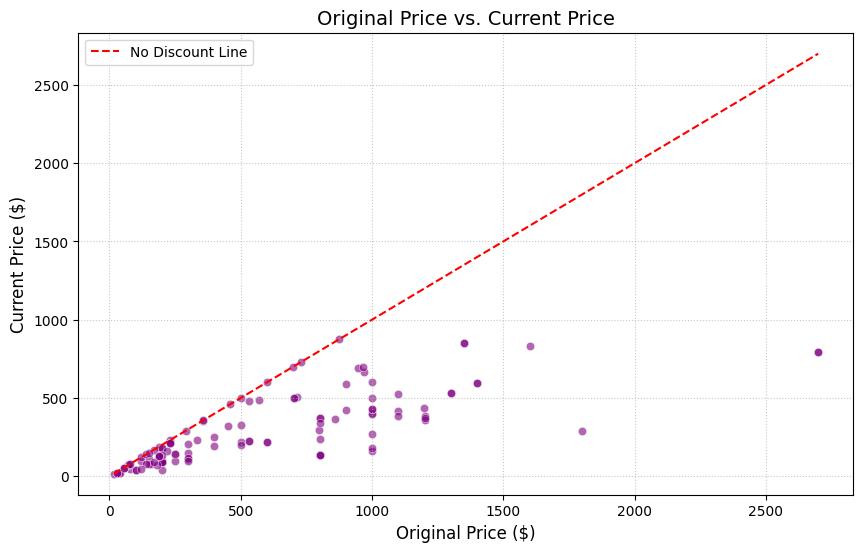

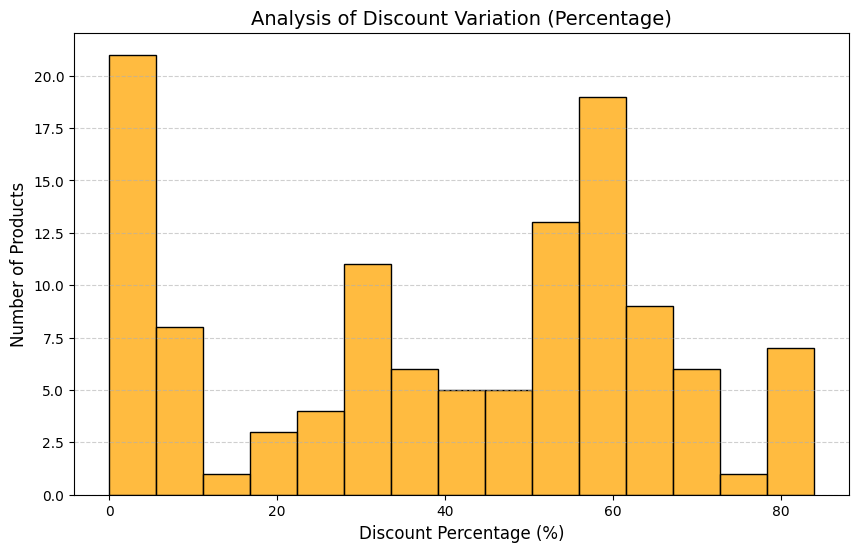

In [2]:
# 2. Price and Discount Analysis
import seaborn as sns
import matplotlib.pyplot as plt

# histogram
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Distribution of Product Prices (Histogram)')
plt.xlabel('Price ($)')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['price'], color='lightgreen')
plt.title('Price Spread and Outliers (Boxplot)')
plt.xlabel('Price ($)')

plt.tight_layout()
plt.show() 

# scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='original_price', y='price', alpha=0.6, color='purple')

# Reference line
line_coords = [df['price'].min(), df['original_price'].max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', label='No Discount Line')

plt.title('Original Price vs. Current Price', fontsize=14)
plt.xlabel('Original Price ($)', fontsize=12)
plt.ylabel('Current Price ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show() 

# histo discount variation
plt.figure(figsize=(10, 6))
sns.histplot(df['discount_percentage'], bins=15, color='orange', edgecolor='black')

plt.title('Analysis of Discount Variation (Percentage)', fontsize=14)
plt.xlabel('Discount Percentage (%)', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show() 

Shipping Option Frequencies:
shipping
Free shipping                84
Shipping info unavailable    35
Name: count, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_10400\2033590781.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shipping_counts.index, y=shipping_counts.values, palette='viridis')


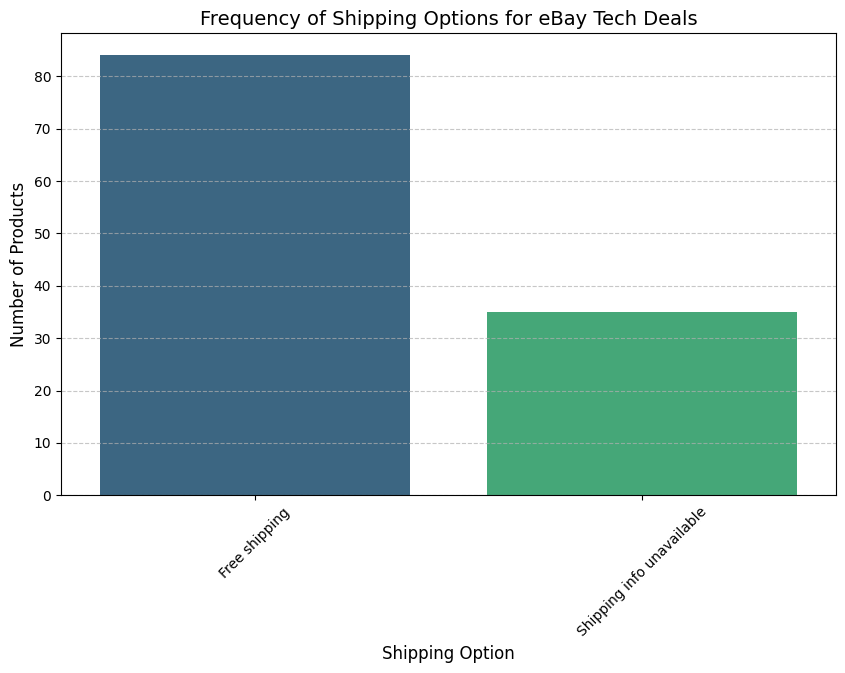

In [3]:
#3. Shipping info analysis
import matplotlib.pyplot as plt
import seaborn as sns

#count the frequemncy
shipping_counts = df['shipping'].value_counts()
print("Shipping Option Frequencies:")
print(shipping_counts)

#bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=shipping_counts.index, y=shipping_counts.values, palette='viridis')

#labels and titles
plt.title('Frequency of Shipping Options for eBay Tech Deals', fontsize=14)
plt.xlabel('Shipping Option', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.xticks(rotation=45)  # Rotate labels if they are long
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_10400\2099423896.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keyword_series.index, y=keyword_series.values, palette='magma')


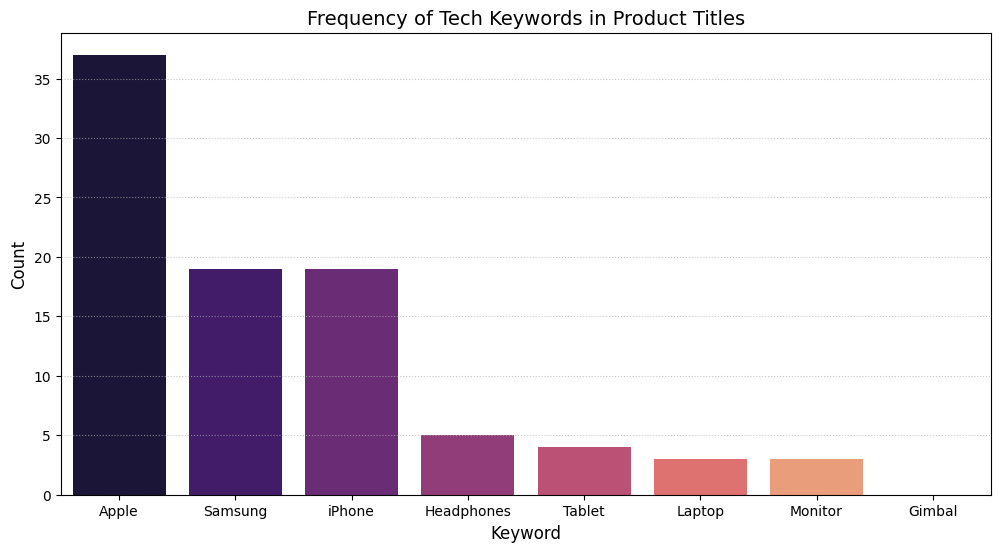

In [4]:
# 4. text analysis on product titles
import matplotlib.pyplot as plt
import seaborn as sns

keywords = ["Apple", "Samsung", "Laptop", "iPhone", "Tablet", "Gimbal", "Monitor", "Headphones"]

# count occurences, to lower case and check if it exists
keyword_counts = {}
for word in keywords:
    count = df['title'].str.contains(word, case=False, na=False).sum()
    keyword_counts[word] = count

keyword_series = pd.Series(keyword_counts).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=keyword_series.index, y=keyword_series.values, palette='magma')

plt.title('Frequency of Tech Keywords in Product Titles', fontsize=14)
plt.xlabel('Keyword', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.show()

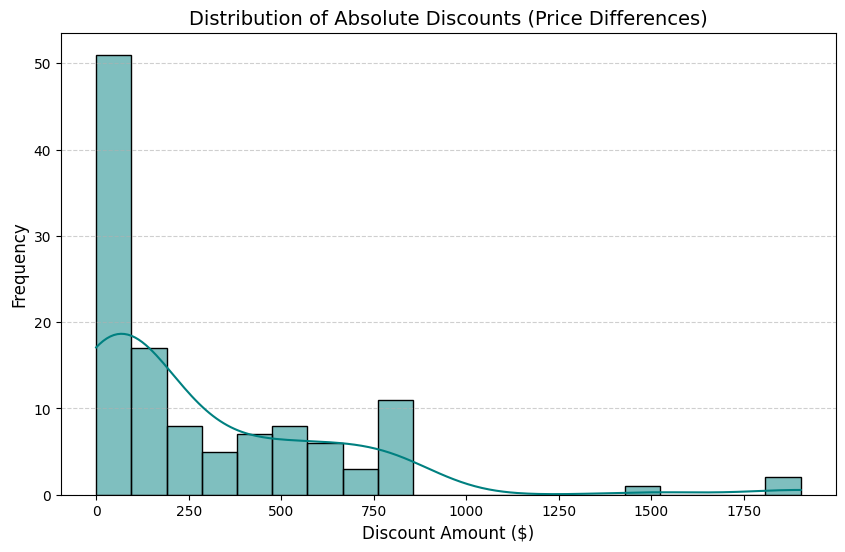

In [5]:
#price difference analysis
import matplotlib.pyplot as plt
import seaborn as sns

# df['absolute_discount'] = df['original_price'] - df['price']

plt.figure(figsize=(10, 6))
sns.histplot(df['discount_amount'].dropna(), bins=20, kde=True, color='teal')

plt.title('Distribution of Absolute Discounts (Price Differences)', fontsize=14)
plt.xlabel('Discount Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [6]:
#discount

top_deals = df.sort_values(by='discount_percentage', ascending=False)
print("--- Top 5 eBay Tech Deals by Discount Percentage ---")
print(top_deals[['title', 'price', 'original_price', 'discount_percentage']].head(5))

--- Top 5 eBay Tech Deals by Discount Percentage ---
                                                 title   price  \
102  Google Pixel Fold 5G 256GB 7.6" T-Mobile Only,...  288.99   
6      Samsung Galaxy S22+ 128GB S906U Unlocked - Good  163.99   
2    Samsung Galaxy S21 5G 128GB G991U Unlocked - Good  134.99   
92   Samsung Galaxy S21 5G 128GB G991U Unlocked - Good  134.99   
42   Samsung Galaxy S21 5G 128GB G991U Unlocked - Good  134.99   

     original_price  discount_percentage  
102         1799.00                83.94  
6            999.99                83.60  
2            799.99                83.13  
92           799.99                83.13  
42           799.99                83.13  
